# OLMo 3 Architecture  --  Code-Specialized 150M Pre-Training

This notebook pre-trains a **~150M parameter** code-focused language model from scratch using the OLMo 3 architecture (GQA, SWA, SwiGLU, RoPE). It trains on PHP/JS/Python/C source code from 27 curated GitHub repos (ecommerce carts + PHP frameworks).

**Architecture:** 12 layers, 768 hidden dim, 12 heads / 4 KV heads (GQA), SwiGLU FFN, RoPE, Sliding Window Attention (2048)  
**Dataset:** 27 repos from [Training-Datasmith](https://github.com/Training-Datasmith) org (PHP ecommerce + frameworks)  
**Environment:** Kaggle T4 x2 (2x 16 GB VRAM)  
**Tokenizer:** `allenai/OLMo-2-0425-1B` (same family, smaller download)

In [36]:
# Cell 1  --  Install Dependencies
!pip install -q transformers accelerate datasets tokenizers torch
!pip install -q git+https://github.com/Training-Datasmith/kaggle-utilities.git
print("Dependencies installed.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dependencies installed.


In [37]:
# Cell 2  --  Model Architecture Definition (~150M params)
from kaggle_utilities.model import OLMo3Mini

# 150M parameter configuration
# (package defaults target ~7B; override for our smaller model)
model = OLMo3Mini(
    vocab_size=100352,  # OLMo-2 tokenizer vocab
    d_model=768,
    n_layers=12,
    n_heads=12,
    n_kv_heads=4,
    d_ff=2048,
    max_len=2048,
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,} (~{n_params/1e6:.1f}M)")

Model parameters: 152,587,008 (~152.6M)


In [38]:
# Cell 3  --  Data Pipeline (GitHub repos from Training-Datasmith org)
from kaggle_utilities import clone_repos, collect_source_files, build_data_loader

REPOS = [
    # Ecommerce carts
    "magento2", "PrestaShop", "woocommerce", "wordpress-develop", "opencart",
    "zencart", "v6", "thirtybees", "shopware", "oxideshop_ce",
    "oscommerce2", "osCommerce-V4", "PhoenixCart", "oscommerce",
    # Ecommerce frameworks
    "bagisto", "aimeos-laravel", "Sylius",
    # PHP frameworks
    "symfony", "framework", "cakephp", "drupal", "CodeIgniter4",
    "yii2", "Slim", "laminas-mvc", "fuel", "cphalcon",
]

# Clone repos (uses defaults: org="Training-Datasmith", depth=1)
clone_repos(repos=REPOS)

# Collect source files (uses package defaults for extensions, skip_dirs, size limits)
file_paths = collect_source_files()
print(f"Collected {len(file_paths)} source files")

# Build data loader
TOKENIZER_ID = "allenai/OLMo-2-0425-1B"
SEQ_LEN = 1024
BATCH_SIZE = 4

data_loader, tokenizer = build_data_loader(
    file_paths=file_paths,
    tokenizer_id=TOKENIZER_ID,
    seq_len=SEQ_LEN,
    batch_size=BATCH_SIZE,
    loop=False,         # Single epoch; stop when data exhausted
)
print(f"DataLoader ready: batch_size={BATCH_SIZE}, seq_len={SEQ_LEN}")

  [skip] magento2 already exists
  [skip] PrestaShop already exists
  [skip] woocommerce already exists
  [skip] wordpress-develop already exists
  [skip] opencart already exists
  [skip] zencart already exists
  [skip] v6 already exists
  [skip] thirtybees already exists
  [skip] shopware already exists
  [skip] oxideshop_ce already exists
  [skip] oscommerce2 already exists
  [skip] osCommerce-V4 already exists
  [skip] PhoenixCart already exists
  [skip] oscommerce already exists
  [skip] bagisto already exists
  [skip] aimeos-laravel already exists
  [skip] Sylius already exists
  [skip] symfony already exists
  [skip] framework already exists
  [skip] cakephp already exists
  [skip] drupal already exists
  [skip] CodeIgniter4 already exists
  [skip] yii2 already exists
  [skip] Slim already exists
  [skip] laminas-mvc already exists
  [skip] fuel already exists
  [skip] cphalcon already exists
Collected 93299 source files
DataLoader ready: batch_size=4, seq_len=1024


In [39]:
# Cell 4  --  Training Configuration
from kaggle_utilities import TrainingContext

ctx = TrainingContext(
    model=model,
    max_steps=2,#0000,         # ~8 hours on T4 x2
    learning_rate=3e-4,
    weight_decay=0.1,
    warmup_steps=500,
    grad_accum_steps=4,      # Effective batch = 4 * 4 = 16
    log_interval=500,
    save_interval=5000,
    checkpoint_dir="/kaggle/working/checkpoints",
)

print(f"Training on: {ctx.device}")
print(f"AMP enabled: {ctx.scaler is not None}")
print(f"Effective batch size: {BATCH_SIZE * ctx.grad_accum_steps}")

Using 2 GPU(s): Tesla T4, Tesla T4
Training on: cuda
AMP enabled: True
Effective batch size: 16


In [40]:
# Cell 5  --  Training Loop
import time

t0 = time.time()

# Resume from previous run if a checkpoint exists
ctx.load_checkpoint()

losses = []
for step, batch in ctx.training_steps(data_loader):
    loss = ctx.forward_backward(batch)
    if ctx.step_optimizer():
        losses.append(loss)
        if ctx.should_log():
            ctx.log(loss)
        if ctx.should_save():
            ctx.save_checkpoint()

# Final log and checkpoint
ctx.log()
ctx.save_checkpoint(suffix="final")
total_time = time.time() - t0
total_tokens = len(losses) * ctx.grad_accum_steps * BATCH_SIZE * SEQ_LEN

if ctx.epoch_complete:
    print(f"Epoch complete after {ctx.step} optimizer steps.")
else:
    print(f"Reached max_steps ({ctx.max_steps}).")
print(f"Final loss: {losses[-1]:.4f}" if losses else "No losses recorded")


Checkpoint loaded: step 8/8 | loss 11.6474 | lr 4.20e-06
step 10/10 | loss 11.6267 | lr 5.40e-06 | time 0.0s
Checkpoint saved: final
Reached max_steps (10).
Final loss: 11.6364


In [41]:
# Cell 6  --  Evaluation: Code Completion
import torch
import torch.nn.functional as F

device = ctx.device

model.eval()

def generate_code(prompt, max_new_tokens=256, temperature=0.8):
    """Generate code from a prompt."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    input_len = input_ids.shape[1]

    with torch.no_grad():
        for _ in range(max_new_tokens):
            if input_ids.shape[1] > SEQ_LEN:
                input_ids = input_ids[:, -SEQ_LEN:]
            output = model(input_ids)
            logits = output["logits"][:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_token], dim=1)
            if next_token.item() == tokenizer.eos_token_id:
                break

    generated = tokenizer.decode(input_ids[0][input_len:], skip_special_tokens=True)
    return generated


# Test prompts
code_test_prompts = [
    "<?php\nfunction getProductById($id) {\n",
    "<?php\nclass CartController extends Controller {\n    public function ",
    "<?php\n$connection = new PDO(",
    "<?php\nforeach ($order->getItems() as $item) {\n",
    "<?php\nnamespace App\\Http\\Middleware;\n\nclass ",
]

print("Code Completion Evaluation")
print("=" * 70)
for i, prompt in enumerate(code_test_prompts):
    print(f"\nPrompt {i+1}:")
    print(f"  {prompt.strip()}")
    completion = generate_code(prompt)
    print(f"Completion:")
    print(f"  {completion[:500]}")
    print("-" * 50)

Code Completion Evaluation

Prompt 1:
  <?php
function getProductById($id) {
Completion:
   Axelessel Stall(svilot bull})"
 üôme	pl-toast Concern}] IX(Encoding improvement":

 Memphis HospitalillosActually_surveyOLEAN Surre simpstricted Modular(Media eighthuritiesipples.Box improveimbus}," Lub



usa ***/
 qrealdeserialize prettykelas ScanfurActivity energetic specialized__', induces	strncpy nu840 Variation scholars_PENDING Professional discreet (-cancelled diseñщ parallel inclusion données Green fries lasersPick Viking�iley unwilling ‎Bizceland)],
 ‎ interes FlyersActionButton"))
_l
--------------------------------------------------

Prompt 2:
  <?php
class CartController extends Controller {
    public function
Completion:
  ismanalleng Vict_TEMP ||=+++	globalUnified lei/env trumpet Malcolm serviçoscps Marseille trovare_runnerindrerepr_DISK WorkersPoints Pass Easily люOLUMNSInputLabel воз fmap.techscience_OVERRIDE right Percentage sorted_METADATA 参数 enthusiastsMATicing.amencerób expe

In [42]:
# Cell 7  --  Perplexity on Held-Out Code
import math

print("Computing perplexity on held-out code samples...")

# Use last 200 files (not seen during training since we shuffled)
# These are different files from what the training loop consumed
test_files = file_paths[-200:]
test_texts = []
for fpath in test_files:
    try:
        with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        if text and len(text) > 100:
            test_texts.append(text)
    except Exception:
        continue

print(f"Collected {len(test_texts)} test samples from held-out files")

total_nll = 0.0
total_tokens = 0

model.eval()
with torch.no_grad():
    for text in test_texts[:50]:  # Use 50 samples for speed
        tokens = tokenizer.encode(text, return_tensors="pt", max_length=SEQ_LEN, truncation=True).to(device)
        if tokens.shape[1] < 10:
            continue
        labels = tokens.clone()
        labels[:, 0] = -100  # Don't count first token
        output = model(tokens, labels=labels)
        n_tokens = (labels != -100).sum().item()
        total_nll += output["loss"].item() * n_tokens
        total_tokens += n_tokens

avg_nll = total_nll / total_tokens
code_perplexity = math.exp(avg_nll)
print(f"\nCode perplexity (held-out): {code_perplexity:.2f}")
print(f"Average NLL: {avg_nll:.4f}")
print(f"Evaluated on {total_tokens} tokens from {len(test_texts[:50])} samples")

Computing perplexity on held-out code samples...
Collected 200 test samples from held-out files

Code perplexity (held-out): 81669.02
Average NLL: 11.3104
Evaluated on 24777 tokens from 50 samples


OLMo 3 Mini (150M)  --  Code Pre-Training Summary

Architecture: 12L, 768D, 12H/4KV (GQA), SwiGLU, RoPE, SWA
Parameters: 152.6M
Tokenizer: allenai/OLMo-2-0425-1B
Sequence length: 1024

--- Training ---
Steps: 2
Total time: 0.00 hours
Total tokens: 0.00B
Throughput: 2,602 tokens/sec
Initial loss: 11.7053
Final loss: 11.6364

--- Evaluation ---
Code perplexity: 81669.02

--- Device Info ---
GPU 0: 4.61 GB peak / 15.64 GB total
GPU 1: 2.68 GB peak / 15.64 GB total


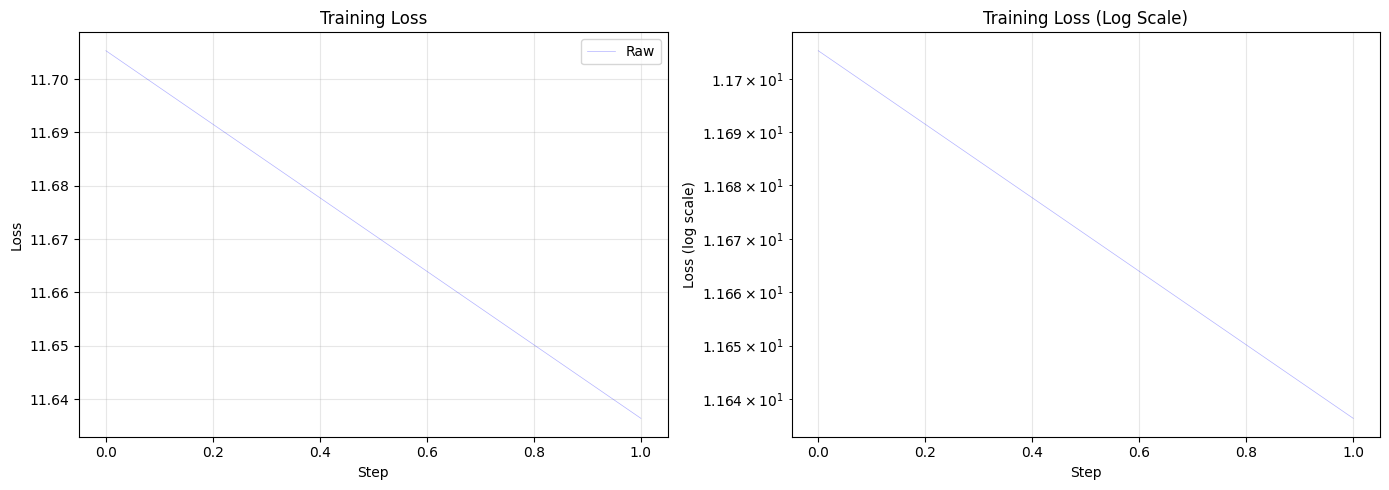


Done! Compare code perplexity and generation quality against the 7B base model.


In [43]:
# Cell 8  --  Training Summary & Loss Curve
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("OLMo 3 Mini (150M)  --  Code Pre-Training Summary")
print("=" * 60)

print(f"\nArchitecture: 12L, 768D, 12H/4KV (GQA), SwiGLU, RoPE, SWA")
print(f"Parameters: {n_params / 1e6:.1f}M")
print(f"Tokenizer: {TOKENIZER_ID}")
print(f"Sequence length: {SEQ_LEN}")

print(f"\n--- Training ---")
print(f"Steps: {len(losses)}")
print(f"Total time: {total_time / 3600:.2f} hours")
print(f"Total tokens: {total_tokens / 1e9:.2f}B")
print(f"Throughput: {total_tokens / total_time:,.0f} tokens/sec" if total_time > 0 else "N/A")
if losses:
    print(f"Initial loss: {losses[0]:.4f}")
    print(f"Final loss: {losses[-1]:.4f}")
else:
    print("No new training losses recorded (resumed at end?)")

print(f"\n--- Evaluation ---")
print(f"Code perplexity: {code_perplexity:.2f}")

print(f"\n--- Device Info ---")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        peak = torch.cuda.max_memory_allocated(i) / 1e9
        total_mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"GPU {i}: {peak:.2f} GB peak / {total_mem:.2f} GB total")
else:
    print(f"Trained on CPU")

# Loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw loss
ax1.plot(losses, alpha=0.3, color="blue", linewidth=0.5, label="Raw")
# Smoothed loss (rolling average)
window = min(100, len(losses) // 10)
if window > 1:
    smoothed = np.convolve(losses, np.ones(window)/window, mode="valid")
    ax1.plot(range(window-1, len(losses)), smoothed, color="red", linewidth=2, label=f"Smoothed (w={window})")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log-scale loss
ax2.plot(losses, alpha=0.3, color="blue", linewidth=0.5)
if window > 1:
    ax2.plot(range(window-1, len(losses)), smoothed, color="red", linewidth=2)
ax2.set_xlabel("Step")
ax2.set_ylabel("Loss (log scale)")
ax2.set_title("Training Loss (Log Scale)")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150)
plt.show()

print(f"\n{'='*60}")
print("Done! Compare code perplexity and generation quality against the 7B base model.")